In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
DATA_PATH = Path("../data/processed/cleaned_grading_dataset.xlsx")

df = pd.read_excel(DATA_PATH)

print(f"Shape: {df.shape}")

Shape: (1055, 116)


In [3]:
df.head()

,Tissue_ID,Eye,Image_ID,Disease_Label,Disease_Severity,ECD_CD_cells_per_mm2,CV,HEX_percent,SD,Total_Cell_Count,...,Epi_Has_Exposure,Epi_Exposure_Severity,Epi_Has_Defect,Epi_Has_Haze,Epi_Haze_Severity,Epi_Exposure_Location,Epi_Has_Arcus,Donor_Graft_Size_Clean_mm,Recipient_Bed_Size_Clean_mm,Previous_Grafts_Clean
0,12346 R (year/month unknown),Right,NaN,Normal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NEB-2020-09-12654 R,Right,NEB-2020-09-12654 R_SP,Normal,NaN,2132.0,33.0,58.0,153.0,24.0,...,0.0,NaN,0.0,0.0,NaN,NaN,0.0,8.25,8.0,NaN
2,NEB-2020-09-12655 L,Left,NEB-2020-09-12655 L_SP,Folds,Moderate,2212.0,33.0,47.0,147.0,70.0,...,1.0,Mild,0.0,0.0,NaN,Peripheral,0.0,NaN,NaN,NaN
3,NEB-2020-09-12656 R,Right,NEB-2020-09-12656 R_SP,Normal,NaN,2538.0,35.0,53.0,137.0,136.0,...,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,1
4,NEB-2020-09-12657 L,Left,NEB-2020-09-12657 L_SP,Folds,Mild,2584.0,29.0,69.0,112.0,115.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.5,2


In [5]:
print(df["Tissue_Grade_Clean"].value_counts(dropna=False))

Tissue_Grade_Clean
A+     545
A      319
B      172
NaN     19
Name: count, dtype: int64


In [7]:
target_counts = (
    df["Tissue_Grade_Clean"]
    .value_counts(dropna=False)
    .rename_axis("Grade")
    .reset_index(name="Count")
)

target_counts["Percentage"] = (
    target_counts["Count"] / len(df) * 100
).round(2)

print(target_counts)

  Grade  Count  Percentage
0    A+    545       51.66
1     A    319       30.24
2     B    172       16.30
3   NaN     19        1.80


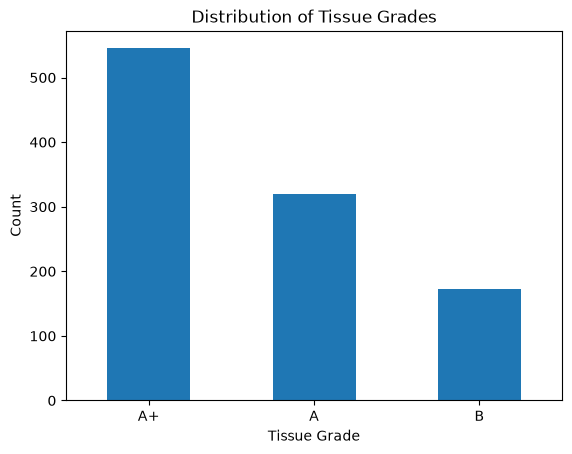

In [8]:
plot_data = (
    df["Tissue_Grade_Clean"]
    .value_counts()
    .reindex(["A+", "A", "B"])
)

plot_data.plot(kind="bar")

plt.title("Distribution of Tissue Grades")
plt.xlabel("Tissue Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [9]:
numeric_features = [
    "ECD_CD_cells_per_mm2",
    "CV",
    "HEX_percent",
    "SD",
    "Total_Cell_Count",
    "Total_Area_um2",
    "Donor_Age",
]

numeric_by_grade = (
    df[df["Tissue_Grade_Clean"].notna()]
    .groupby("Tissue_Grade_Clean")[numeric_features]
    .agg(["count", "mean", "median", "std"])
)

print(numeric_by_grade)

                   ECD_CD_cells_per_mm2                                   \
                                  count         mean  median         std   
Tissue_Grade_Clean                                                         
A                                   281  2533.583630  2415.0  341.467067   
A+                                  505  2813.380198  2762.0  258.603772   
B                                   154  1944.110390  2024.0  378.747326   

                      CV                             HEX_percent             \
                   count       mean median       std       count       mean   
Tissue_Grade_Clean                                                            
A                    281  38.822064   38.0  5.064267         281  52.302491   
A+                   505  37.465347   37.0  4.224279         505  55.269307   
B                    154  39.201299   38.0  6.630667         154  53.097403   

                    ... Total_Cell_Count            Total_Area_um2  

In [10]:
pd.set_option("display.max_columns", None)

print(numeric_by_grade)

                   ECD_CD_cells_per_mm2                                   \
                                  count         mean  median         std   
Tissue_Grade_Clean                                                         
A                                   281  2533.583630  2415.0  341.467067   
A+                                  505  2813.380198  2762.0  258.603772   
B                                   154  1944.110390  2024.0  378.747326   

                      CV                             HEX_percent             \
                   count       mean median       std       count       mean   
Tissue_Grade_Clean                                                            
A                    281  38.822064   38.0  5.064267         281  52.302491   
A+                   505  37.465347   37.0  4.224279         505  55.269307   
B                    154  39.201299   38.0  6.630667         154  53.097403   

                                       SD                           

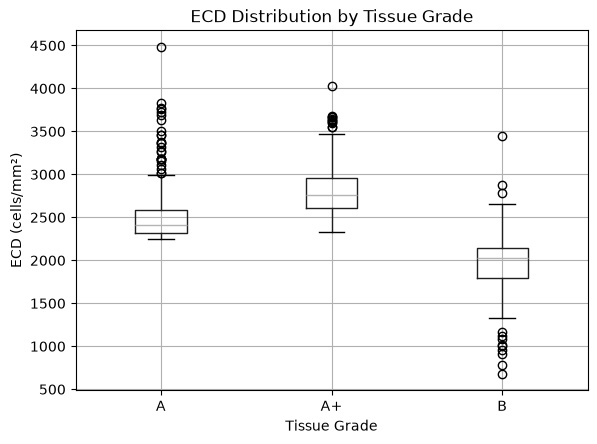

In [11]:
plot_df = df[
    df["Tissue_Grade_Clean"].notna()
][["Tissue_Grade_Clean", "ECD_CD_cells_per_mm2"]].dropna()

plot_df.boxplot(
    column="ECD_CD_cells_per_mm2",
    by="Tissue_Grade_Clean"
)

plt.title("ECD Distribution by Tissue Grade")
plt.suptitle("")
plt.xlabel("Tissue Grade")
plt.ylabel("ECD (cells/mm²)")
plt.show()

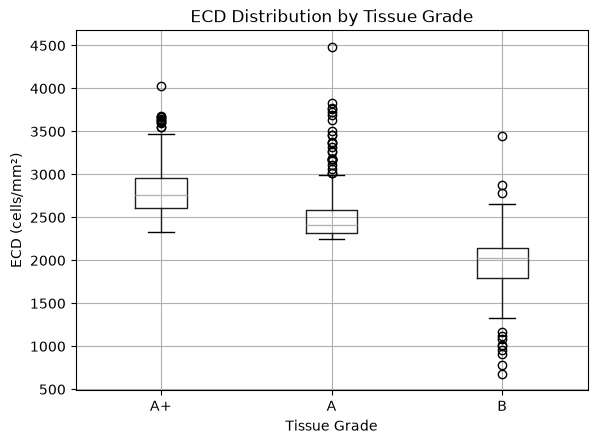

In [12]:
plot_df = df[
    df["Tissue_Grade_Clean"].notna()
][["Tissue_Grade_Clean", "ECD_CD_cells_per_mm2"]].dropna()

plot_df["Tissue_Grade_Clean"] = pd.Categorical(
    plot_df["Tissue_Grade_Clean"],
    categories=["A+", "A", "B"],
    ordered=True
)

plot_df.boxplot(
    column="ECD_CD_cells_per_mm2",
    by="Tissue_Grade_Clean"
)

plt.title("ECD Distribution by Tissue Grade")
plt.suptitle("")
plt.xlabel("Tissue Grade")
plt.ylabel("ECD (cells/mm²)")
plt.show()

In [13]:
def ecd_rule_grade(ecd):
    if pd.isna(ecd):
        return pd.NA
    if ecd > 3000:
        return "A+"
    if 2500 <= ecd <= 3000:
        return "A"
    if 2000 <= ecd < 2500:
        return "B"
    return pd.NA


df["ECD_Rule_Grade"] = df["ECD_CD_cells_per_mm2"].apply(ecd_rule_grade)

In [15]:
print(pd.crosstab(
    df["Tissue_Grade_Clean"],
    df["ECD_Rule_Grade"],
    dropna=False
))

ECD_Rule_Grade        A   A+    B  NaN
Tissue_Grade_Clean                    
A                    75   25  181   38
A+                  397  106    2   40
B                     5    1   86   80
NaN                   3    6    3    7


In [17]:
comparison = df[
    df["Tissue_Grade_Clean"].notna()
].copy()

comparison["ECD_Rule_Match"] = (
    comparison["Tissue_Grade_Clean"]
    == comparison["ECD_Rule_Grade"]
)

print(comparison["ECD_Rule_Match"].value_counts(dropna=False))

ECD_Rule_Match
False    769
True     267
Name: count, dtype: int64


In [18]:
rule_evaluable = comparison[
    comparison["ECD_Rule_Grade"].notna()
]

print("Evaluable records:", len(rule_evaluable))

print(
    "ECD rule agreement:",
    round(
        rule_evaluable["ECD_Rule_Match"].mean() * 100,
        2
    ),
    "%"
)

Evaluable records: 878
ECD rule agreement: 30.41 %


In [20]:
grade_agreement = (
    rule_evaluable
    .groupby("Tissue_Grade_Clean")["ECD_Rule_Match"]
    .agg(["count", "sum", "mean"])
)

grade_agreement["Agreement_Percent"] = (
    grade_agreement["mean"] * 100
).round(2)

print(grade_agreement)

                    count  sum      mean  Agreement_Percent
Tissue_Grade_Clean                                         
A                     281   75  0.266904              26.69
A+                    505  106  0.209901              20.99
B                      92   86  0.934783              93.48


In [21]:
discordant = rule_evaluable[
    ~rule_evaluable["ECD_Rule_Match"]
].copy()

print("Discordant cases:", len(discordant))

Discordant cases: 611


In [23]:
print(pd.crosstab(
    discordant["Tissue_Grade_Clean"],
    discordant["ECD_Rule_Grade"]
))

ECD_Rule_Grade        A  A+    B
Tissue_Grade_Clean              
A                     0  25  181
A+                  397   0    2
B                     5   1    0


In [25]:
print(discordant[
    [
        "Tissue_Grade_Clean",
        "ECD_Rule_Grade",
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "SD",
        "Total_Cell_Count",
        "Total_Area_um2",
        "Donor_Age",
    ]
].groupby(
    ["Tissue_Grade_Clean", "ECD_Rule_Grade"]
).agg(["count", "mean", "median"]))

                                  ECD_CD_cells_per_mm2                       \
                                                 count         mean  median   
Tissue_Grade_Clean ECD_Rule_Grade                                             
A                  A+                               25  3414.200000  3367.0   
                   B                               181  2348.209945  2336.0   
A+                 A                               397  2711.000000  2695.0   
                   B                                 2  2373.500000  2373.5   
B                  A                                 5  2697.800000  2653.0   
                   A+                                1  3448.000000  3448.0   

                                     CV                   HEX_percent  \
                                  count       mean median       count   
Tissue_Grade_Clean ECD_Rule_Grade                                       
A                  A+                25  41.880000   41.0          25

In [27]:
discordance_summary = (
    rule_evaluable
    .assign(
        ECD_Discordant=~rule_evaluable["ECD_Rule_Match"]
    )
    .groupby("ECD_Discordant")[
        [
            "ECD_CD_cells_per_mm2",
            "CV",
            "HEX_percent",
            "SD",
            "Total_Cell_Count",
            "Total_Area_um2",
            "Donor_Age",
        ]
    ]
    .agg(["count", "mean", "median"])
)

print(discordance_summary)

               ECD_CD_cells_per_mm2                         CV             \
                              count         mean  median count       mean   
ECD_Discordant                                                              
False                           267  2710.606742  2732.0   267  38.288390   
True                            611  2632.294599  2597.0   611  37.890344   

                      HEX_percent                      SD                     \
               median       count       mean median count        mean median   
ECD_Discordant                                                                 
False            38.0         267  53.183521   53.0   267  145.883895  141.0   
True             38.0         611  54.466448   54.0   611  145.306056  144.0   

               Total_Cell_Count                    Total_Area_um2  \
                          count        mean median          count   
ECD_Discordant                                                      
False 

In [28]:
a_plus_as_a = rule_evaluable[
    (rule_evaluable["Tissue_Grade_Clean"] == "A+") &
    (rule_evaluable["ECD_Rule_Grade"] == "A")
].copy()

In [29]:
a_plus_correct = rule_evaluable[
    (rule_evaluable["Tissue_Grade_Clean"] == "A+") &
    (rule_evaluable["ECD_Rule_Grade"] == "A+")
].copy()

In [30]:
a_plus_comparison = pd.DataFrame({
    "A+ specialist / ECD=A": a_plus_as_a[
        [
            "ECD_CD_cells_per_mm2",
            "CV",
            "HEX_percent",
            "SD",
            "Total_Cell_Count",
            "Total_Area_um2",
            "Donor_Age",
        ]
    ].mean(),

    "A+ specialist / ECD=A+": a_plus_correct[
        [
            "ECD_CD_cells_per_mm2",
            "CV",
            "HEX_percent",
            "SD",
            "Total_Cell_Count",
            "Total_Area_um2",
            "Donor_Age",
        ]
    ].mean(),
})

print(a_plus_comparison)

                      A+ specialist / ECD=A  A+ specialist / ECD=A+
ECD_CD_cells_per_mm2            2711.000000             3205.122642
CV                                37.370277               37.754717
HEX_percent                       55.307305               55.254717
SD                               138.251889              117.849057
Total_Cell_Count                 109.060453              111.292453
Total_Area_um2                 40369.158690            34847.169811
Donor_Age                         58.272727               55.209524


In [5]:
numeric_features = [
    "ECD_CD_cells_per_mm2",
    "CV",
    "HEX_percent",
    "SD",
    "Total_Cell_Count",
    "Total_Area_um2",
    "Donor_Age",
]

grade_feature_summary = (
    df[df["Tissue_Grade_Clean"].isin(["A+", "A", "B"])]
    .groupby("Tissue_Grade_Clean")[numeric_features]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print(grade_feature_summary)

                   ECD_CD_cells_per_mm2                             CV         \
                                  count     mean  median     std count   mean   
Tissue_Grade_Clean                                                              
A                                   281  2533.58  2415.0  341.47   281  38.82   
A+                                  505  2813.38  2762.0  258.60   505  37.47   
B                                   154  1944.11  2024.0  378.75   154  39.20   

                                HEX_percent         ... Total_Cell_Count  \
                   median   std       count   mean  ...           median   
Tissue_Grade_Clean                                  ...                    
A                    38.0  5.06         281  52.30  ...            108.0   
A+                   37.0  4.22         505  55.27  ...            108.0   
B                    38.0  6.63         154  53.10  ...            104.0   

                          Total_Area_um2                

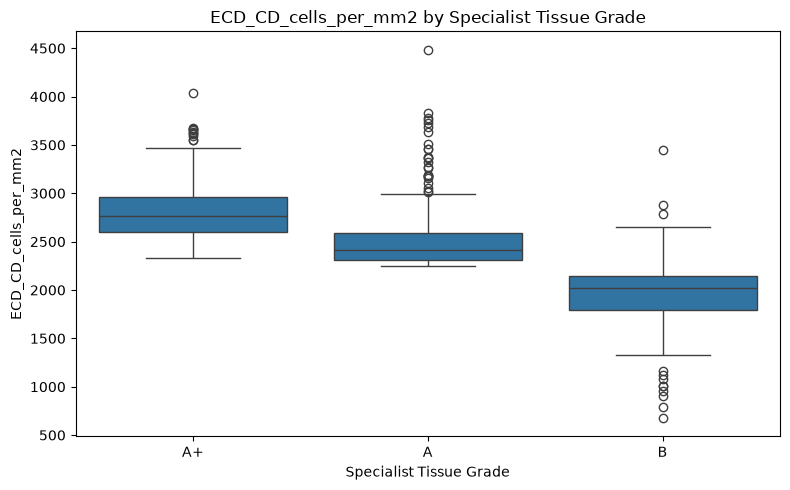

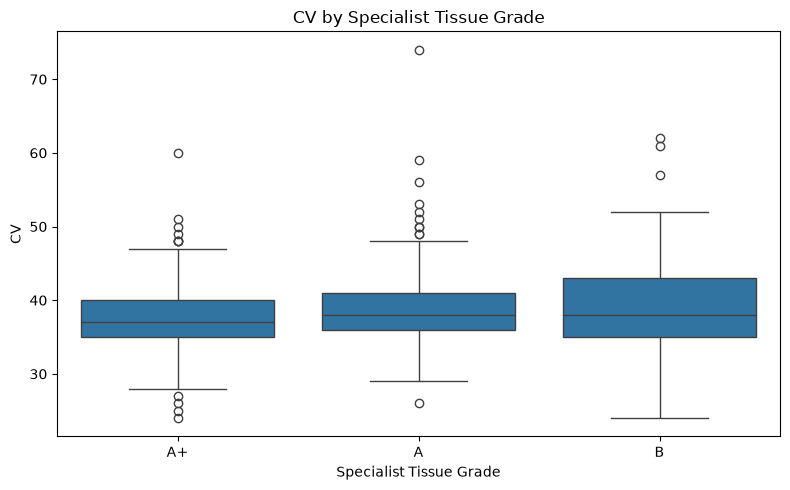

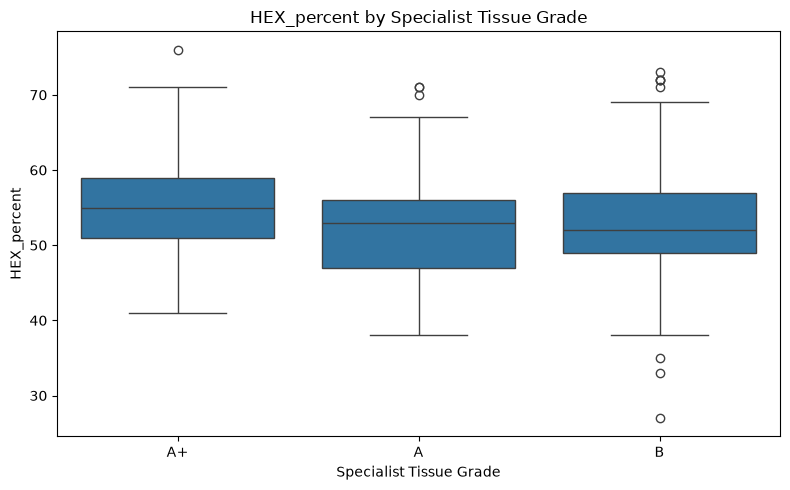

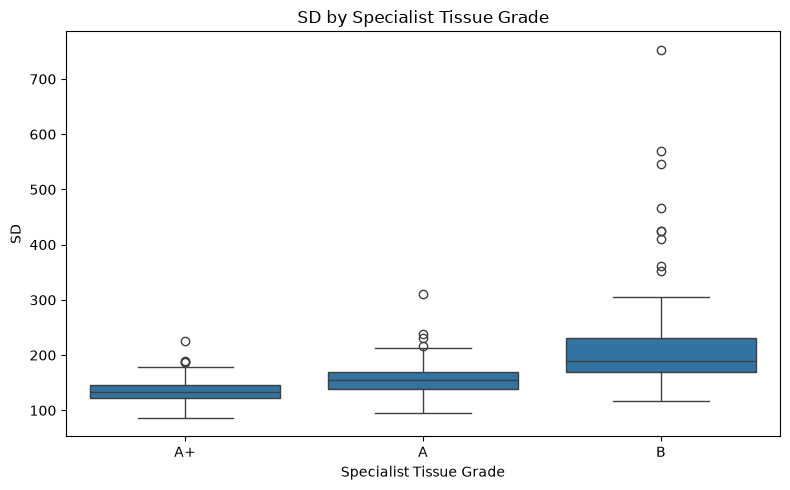

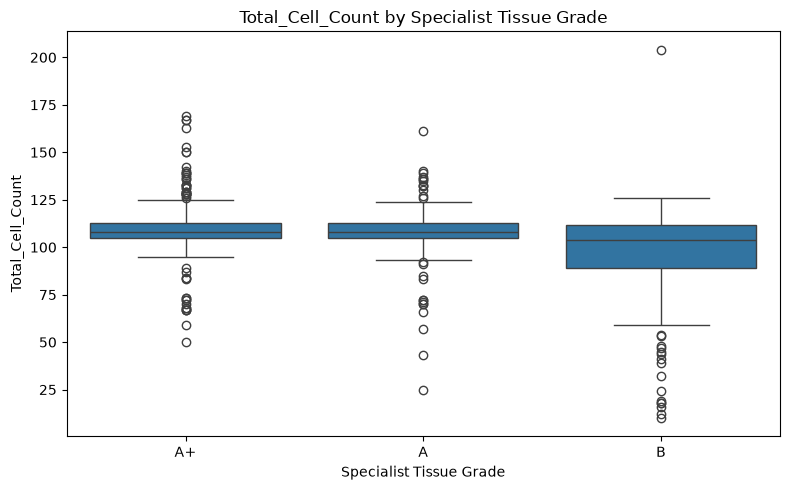

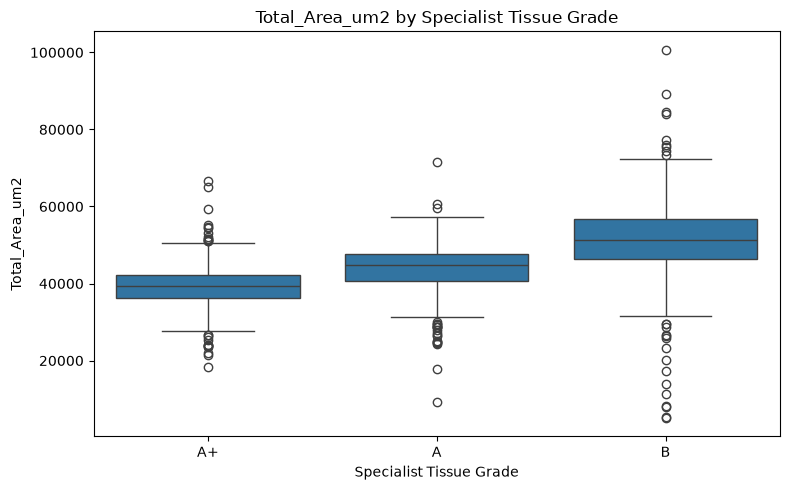

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = [
    "ECD_CD_cells_per_mm2",
    "CV",
    "HEX_percent",
    "SD",
    "Total_Cell_Count",
    "Total_Area_um2",
]

grade_order = ["A+", "A", "B"]

eda_df = df[
    df["Tissue_Grade_Clean"].isin(grade_order)
].copy()

for feature in numeric_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=eda_df,
        x="Tissue_Grade_Clean",
        y=feature,
        order=grade_order,
    )

    plt.title(f"{feature} by Specialist Tissue Grade")
    plt.xlabel("Specialist Tissue Grade")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

clinical_features = [
    "Stroma_Is_Clear",
    "Stroma_Has_Edema",
    "Stroma_Has_Scar",
    "Descemet_Has_Folds",
    "Endo_Has_Cell_Dropout",
    "Endo_Has_Stress_Lines",
    "Epi_Has_Defect",
    "Epi_Has_Haze",
]

clinical_df = df[
    df["Tissue_Grade_Clean"].isin(["A+", "A", "B"])
].copy()

for feature in clinical_features:
    print(f"\n{feature}")

    counts = pd.crosstab(
        clinical_df["Tissue_Grade_Clean"],
        clinical_df[feature],
        dropna=False,
    )

    print(counts)



Stroma_Is_Clear
Stroma_Is_Clear     0.0  1.0  NaN
Tissue_Grade_Clean               
A                     2  198  119
A+                    5  284  256
B                     2   82   88

Stroma_Has_Edema
Stroma_Has_Edema    0.0  1.0  NaN
Tissue_Grade_Clean               
A                   196    4  119
A+                  284    5  256
B                    83    1   88

Stroma_Has_Scar
Stroma_Has_Scar     0.0  1.0  NaN
Tissue_Grade_Clean               
A                   188   12  119
A+                  289    0  256
B                    63   21   88

Descemet_Has_Folds
Descemet_Has_Folds  0.0  1.0  NaN
Tissue_Grade_Clean               
A                     3  179  137
A+                    2  268  275
B                     1   76   95

Endo_Has_Cell_Dropout
Endo_Has_Cell_Dropout  0.0  1.0  NaN
Tissue_Grade_Clean                  
A                      165   34  120
A+                     240   43  262
B                       65   14   93

Endo_Has_Stress_Lines
Endo_Has_Stress_L

In [9]:

import pandas as pd

# Recreate the ECD rule
def ecd_rule_grade(ecd):
    if pd.isna(ecd):
        return pd.NA
    if ecd > 3000:
        return "A+"
    if 2500 <= ecd <= 3000:
        return "A"
    if 2000 <= ecd < 2500:
        return "B"
    return pd.NA

df["ECD_Rule_Grade"] = (
    df["ECD_CD_cells_per_mm2"].apply(ecd_rule_grade)
)

# Keep only records with a specialist grade and an ECD-rule grade
rule_evaluable = df[
    df["Tissue_Grade_Clean"].isin(["A+", "A", "B"]) &
    df["ECD_Rule_Grade"].notna()
].copy()

print("Rule-evaluable records:", len(rule_evaluable))
print("\nSpecialist grade counts:")
print(rule_evaluable["Tissue_Grade_Clean"].value_counts())

print("\nECD rule grade counts:")
print(rule_evaluable["ECD_Rule_Grade"].value_counts())


Rule-evaluable records: 878

Specialist grade counts:
Tissue_Grade_Clean
A+    505
A     281
B      92
Name: count, dtype: int64

ECD rule grade counts:
ECD_Rule_Grade
A     477
B     269
A+    132
Name: count, dtype: int64


In [10]:

a_plus_as_a = rule_evaluable[
    (rule_evaluable["Tissue_Grade_Clean"] == "A+") &
    (rule_evaluable["ECD_Rule_Grade"] == "A")
].copy()

a_plus_correct = rule_evaluable[
    (rule_evaluable["Tissue_Grade_Clean"] == "A+") &
    (rule_evaluable["ECD_Rule_Grade"] == "A+")
].copy()

features_to_compare = [
    "Stroma_Has_Scar",
    "Stroma_Has_Edema",
    "Endo_Has_Cell_Dropout",
    "Endo_Has_Stress_Lines",
    "Epi_Has_Haze",
]

for feature in features_to_compare:
    print(f"\n{feature}")

    for group_name, group in [
        ("A+ specialist / ECD=A", a_plus_as_a),
        ("A+ specialist / ECD=A+", a_plus_correct),
    ]:
        recorded = group[feature].dropna()

        print(
            f"{group_name}: "
            f"n={len(group)}, "
            f"recorded={len(recorded)}, "
            f"missing={group[feature].isna().sum()}, "
            f"present={recorded.eq(True).sum()}, "
            f"present_pct="
            f"{recorded.eq(True).mean() * 100:.1f}%"
            if len(recorded) else
            f"{group_name}: no recorded values"
        )



Stroma_Has_Scar
A+ specialist / ECD=A: n=397, recorded=175, missing=222, present=0, present_pct=0.0%
A+ specialist / ECD=A+: n=106, recorded=72, missing=34, present=0, present_pct=0.0%

Stroma_Has_Edema
A+ specialist / ECD=A: n=397, recorded=175, missing=222, present=3, present_pct=1.7%
A+ specialist / ECD=A+: n=106, recorded=72, missing=34, present=1, present_pct=1.4%

Endo_Has_Cell_Dropout
A+ specialist / ECD=A: n=397, recorded=172, missing=225, present=16, present_pct=9.3%
A+ specialist / ECD=A+: n=106, recorded=70, missing=36, present=13, present_pct=18.6%

Endo_Has_Stress_Lines
A+ specialist / ECD=A: n=397, recorded=172, missing=225, present=161, present_pct=93.6%
A+ specialist / ECD=A+: n=106, recorded=70, missing=36, present=60, present_pct=85.7%

Epi_Has_Haze
A+ specialist / ECD=A: n=397, recorded=174, missing=223, present=7, present_pct=4.0%
A+ specialist / ECD=A+: n=106, recorded=72, missing=34, present=2, present_pct=2.8%
